> **Citation.** If you use DynaTab in your work, please cite:  
> *Al Zadid Sultan Bin Habib, Gianfranco Doretto, and Donald A. Adjeroh.*  
> **DynaTab: Dynamic Feature Ordering as Neural Rewiring for High-Dimensional Tabular Data.**  
> In **AAAI 2026 First International Workshop on Neuro for AI & AI for Neuro: Towards Multi-Modal Natural Intelligence (NeuroAI) Workshop Proceedings (PMLR)**.
> Shorter citation: A. Z. S. B. Habib, G. Doretto, and D. A. Adjeroh, *“DynaTab: Dynamic Feature Ordering as Neural Rewiring for High-Dimensional Tabular Data,”* AAAI 2026 NeuroAI Workshop Proceedings (PMLR).

In [9]:
from dynatab import TabularIDFAnalyzer, analyze_many

# The following code cells illustrate how to use DynaTab and assess when feature ordering is appropriate for your dataset.

# For Single dataset

=== IDF / FOE Analysis Summary ===
Dataset:              EEG-FE
n_samples x n_features: 2132 x 2548

Mean IDF:             0.132653
AUC (cumvar vs IDF):  2.306818e-01
psi* (AUC^s):         5.321411e-02
Loss(psi*):           0.000000e+00
Complexity score:     3.919504e+02
FOE:                  5.682840e+01

=== Threshold-wise details ===
thr	k	IDF		cumvar@k	P_success	Complexity_thr
0.9000	67	0.026295	0.900543	0.973705	1.302427e+03
0.9500	168	0.065934	0.950207	0.934066	2.185740e+02
0.9900	445	0.174647	0.990052	0.825353	3.245913e+01
0.9975	672	0.263736	0.997513	0.736264	1.434097e+01


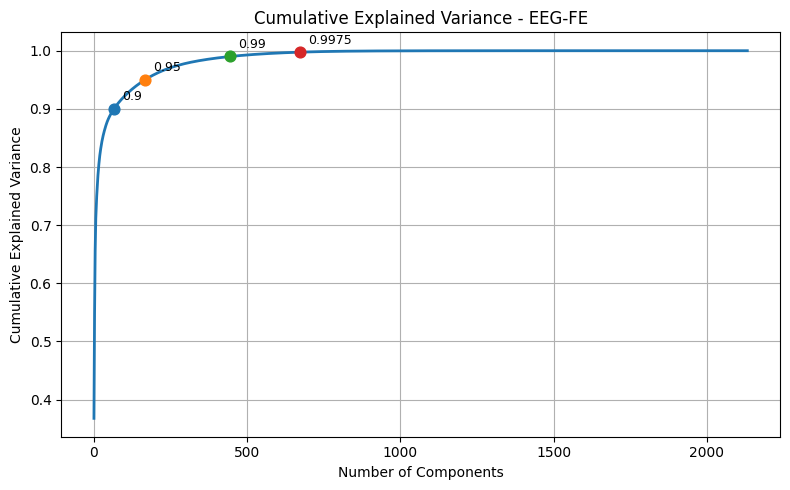

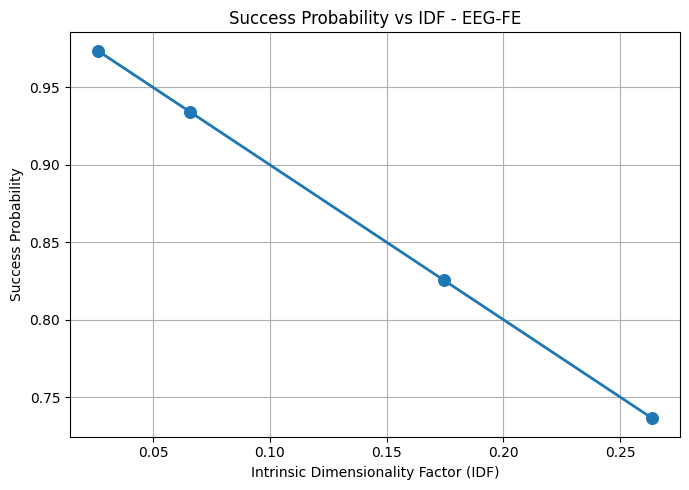

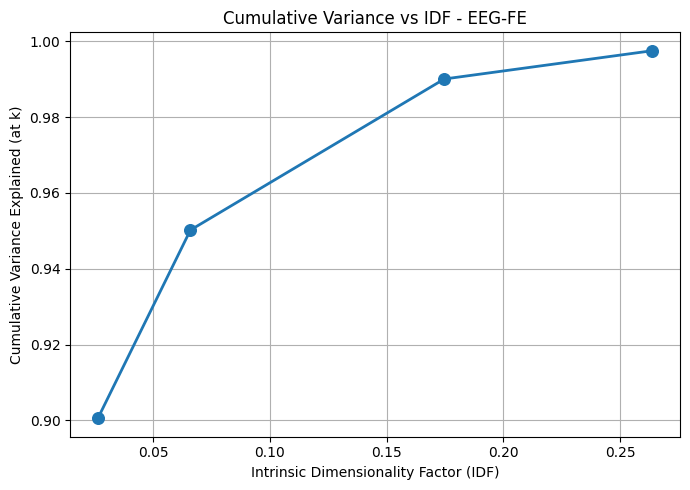


Saved figure paths:
  cumvar_curve: eegfe_cumvar_curve.png
  successprob_vs_idf: eegfe_successprob_vs_idf.png
  cumvar_vs_idf: eegfe_cumvar_vs_idf.png


In [4]:
import pandas as pd
import matplotlib.pyplot as plt

from dynatab.idf_analyzer import TabularIDFAnalyzer

# ------------------------------------------------------------------
# Load data
# ------------------------------------------------------------------
X = pd.read_csv("emotions.csv").drop(columns=["label"])

analyzer = TabularIDFAnalyzer(
    variance_thresholds=(0.90, 0.95, 0.99, 0.9975),
    scale="zscore",
    zscore_axis=0,          # feature-wise standardization (recommended)
    impute="mean",
)

# ------------------------------------------------------------------
# Run analysis
# ------------------------------------------------------------------
res = analyzer.analyze(X, dataset_name="EEG-FE")

# ------------------------------------------------------------------
# Print dataset-level summary
# ------------------------------------------------------------------
print("=== IDF / FOE Analysis Summary ===")
print(f"Dataset:              {res.dataset_name}")
print(f"n_samples x n_features: {res.n_samples} x {res.n_features}")
print()
print(f"Mean IDF:             {res.mean_idf:.6f}")
print(f"AUC (cumvar vs IDF):  {res.auc_cumvar_vs_idf:.6e}")
print(f"psi* (AUC^s):         {res.psi_star:.6e}")
print(f"Loss(psi*):           {res.loss:.6e}")
print(f"Complexity score:     {res.complexity_score:.6e}")
print(f"FOE:                  {res.foe:.6e}")
print()

# ------------------------------------------------------------------
# Print threshold-wise details (per variance threshold)
# ------------------------------------------------------------------
print("=== Threshold-wise details ===")
print("thr\tk\tIDF\t\tcumvar@k\tP_success\tComplexity_thr")
for tr in res.threshold_results:
    print(
        f"{tr.variance_threshold:.4f}\t"
        f"{tr.intrinsic_dim:d}\t"
        f"{tr.idf:.6f}\t"
        f"{tr.cumvar_at_k:.6f}\t"
        f"{tr.success_prob:.6f}\t"
        f"{tr.complexity_at_thr:.6e}"
    )

# ------------------------------------------------------------------
# Display figures
# ------------------------------------------------------------------
# 1) Cumulative explained variance vs components
fig1, ax1 = plt.subplots(figsize=(8, 5))
TabularIDFAnalyzer.plot_cumulative_variance_curve(
    result=res,
    ax=ax1,
    title=f"Cumulative Explained Variance - {res.dataset_name}",
)
fig1.tight_layout()
plt.show()

# 2) Success probability vs IDF
fig2, ax2 = plt.subplots(figsize=(7, 5))
TabularIDFAnalyzer.plot_success_prob_vs_idf(
    result=res,
    ax=ax2,
    title=f"Success Probability vs IDF - {res.dataset_name}",
)
fig2.tight_layout()
plt.show()

# 3) Cumulative variance vs IDF
fig3, ax3 = plt.subplots(figsize=(7, 5))
TabularIDFAnalyzer.plot_cumvar_vs_idf(
    result=res,
    ax=ax3,
    title=f"Cumulative Variance vs IDF - {res.dataset_name}",
)
fig3.tight_layout()
plt.show()

# ------------------------------------------------------------------
# Optionally: also save all three figures to disk
# ------------------------------------------------------------------
paths = TabularIDFAnalyzer.save_all_figures(res, out_prefix="eegfe")
print("\nSaved figure paths:")
for k, v in paths.items():
    print(f"  {k}: {v}")

# For Multiple dataset

=== Dataset-level summary (comparison) ===
Name		Mean IDF	AUC(cumvar vs IDF)	Loss		Complexity	FOE
AI-D    	0.220812	3.498419e-01	0.000000e+00	9.266419e+01	2.050945e+01
ADNI    	0.269886	2.821600e-01	0.000000e+00	2.335942e+01	1.372898e+01
GLI-85  	0.003321	1.027050e-03	0.000000e+00	9.084735e+04	9.068237e+04

=== Detailed IDF / FOE Analysis — AI-D ===
Dataset:              AI-D
n_samples x n_features: 239 x 394

Mean IDF:             0.220812
AUC (cumvar vs IDF):  3.498419e-01
Loss:                 0.000000e+00
Complexity score:     9.266419e+01
FOE:                  2.050945e+01

Threshold-wise details:
thr	k	IDF		cumvar@k	P_success
0.9000	22	0.055838	0.901004	0.944162
0.9500	48	0.121827	0.951179	0.878173
0.9900	114	0.289340	0.990200	0.710660
0.9975	164	0.416244	0.997555	0.583756


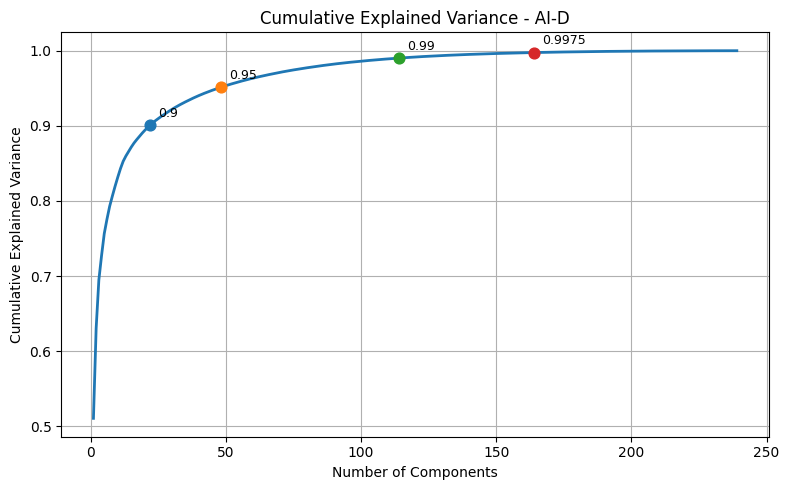

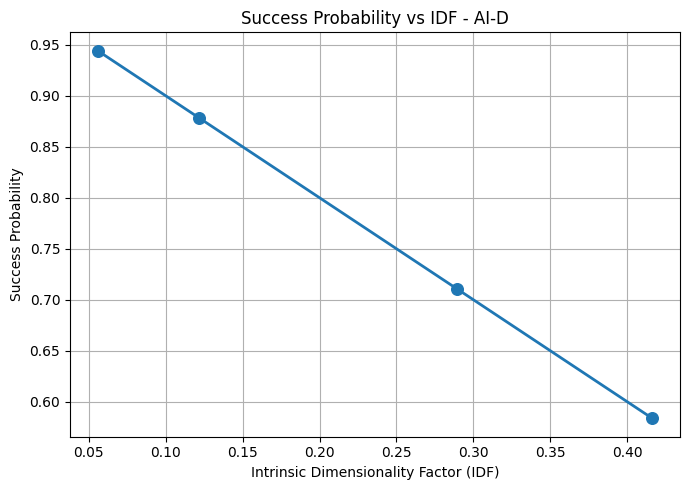

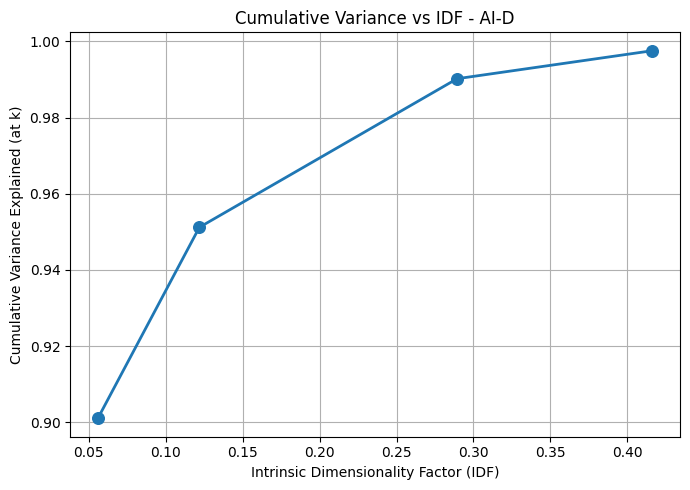


Saved figure paths:
  cumvar_curve: idf_aid_cumvar_curve.png
  successprob_vs_idf: idf_aid_successprob_vs_idf.png
  cumvar_vs_idf: idf_aid_cumvar_vs_idf.png

=== Detailed IDF / FOE Analysis — ADNI ===
Dataset:              ADNI
n_samples x n_features: 177 x 264

Mean IDF:             0.269886
AUC (cumvar vs IDF):  2.821600e-01
Loss:                 0.000000e+00
Complexity score:     2.335942e+01
FOE:                  1.372898e+01

Threshold-wise details:
thr	k	IDF		cumvar@k	P_success
0.9000	34	0.128788	0.901654	0.871212
0.9500	52	0.196970	0.951266	0.803030
0.9900	88	0.333333	0.990460	0.666667
0.9975	111	0.420455	0.997617	0.579545


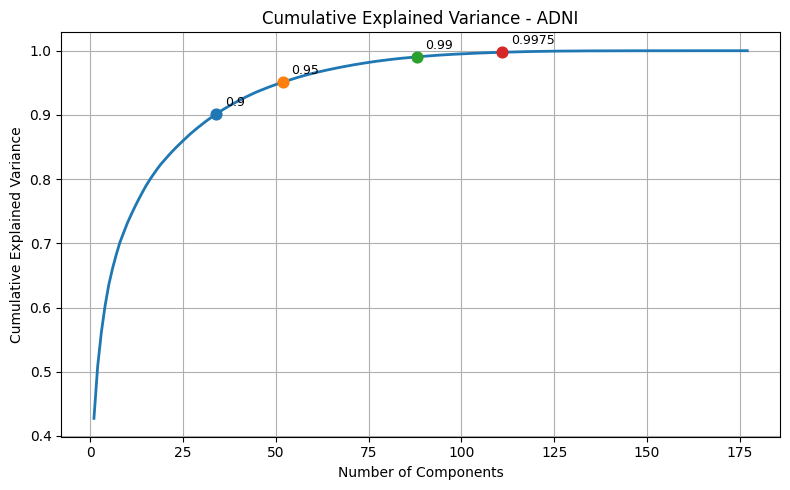

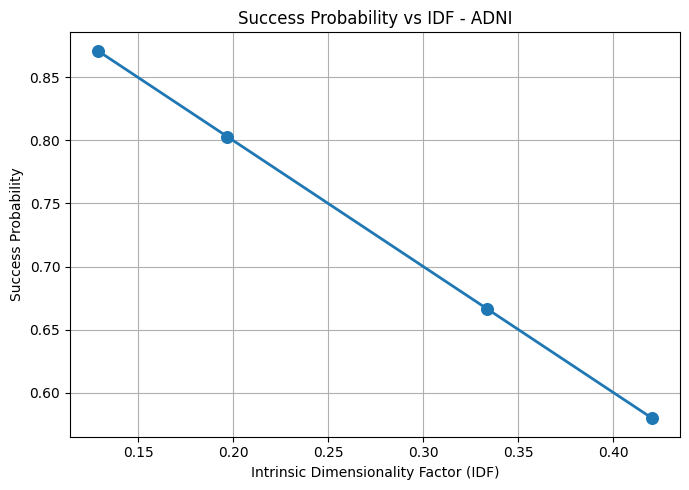

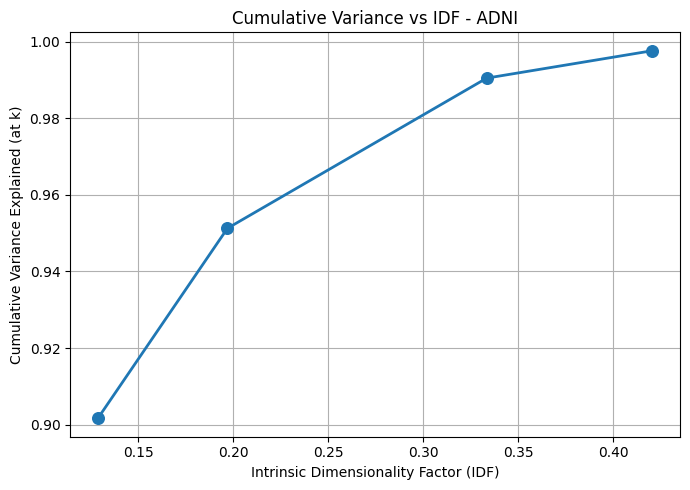


Saved figure paths:
  cumvar_curve: idf_adni_cumvar_curve.png
  successprob_vs_idf: idf_adni_successprob_vs_idf.png
  cumvar_vs_idf: idf_adni_cumvar_vs_idf.png

=== Detailed IDF / FOE Analysis — GLI-85 ===
Dataset:              GLI-85
n_samples x n_features: 85 x 22284

Mean IDF:             0.003321
AUC (cumvar vs IDF):  1.027050e-03
Loss:                 0.000000e+00
Complexity score:     9.084735e+04
FOE:                  9.068237e+04

Threshold-wise details:
thr	k	IDF		cumvar@k	P_success
0.9000	60	0.002693	0.901184	0.997307
0.9500	71	0.003186	0.951771	0.996814
0.9900	81	0.003635	0.990256	0.996365
0.9975	84	0.003770	1.000000	0.996230


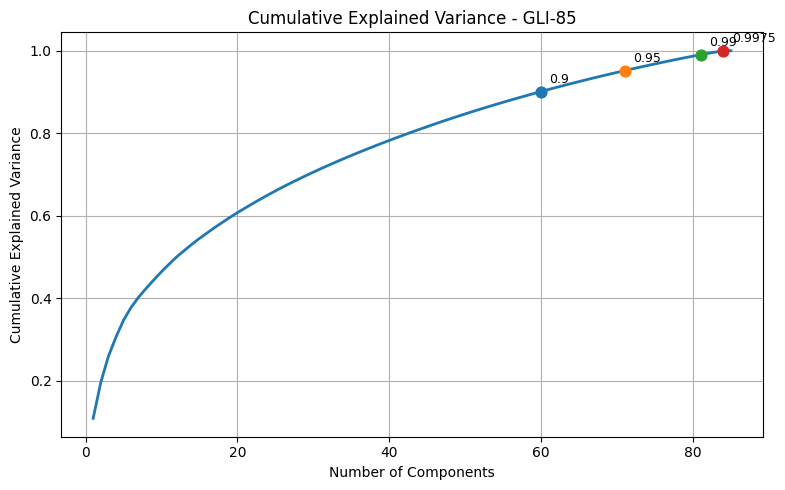

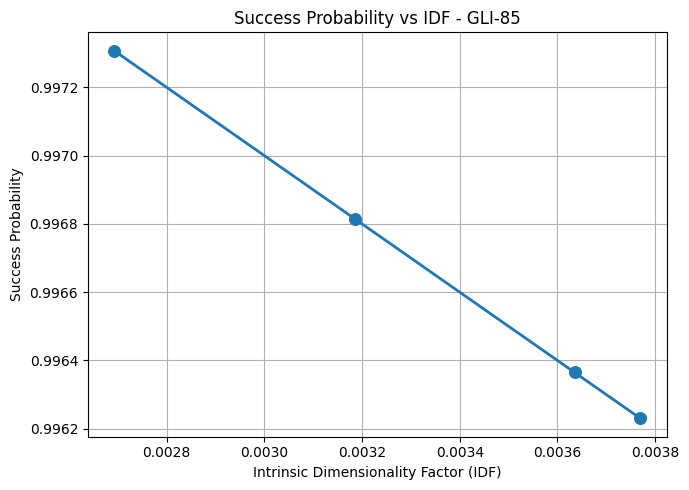

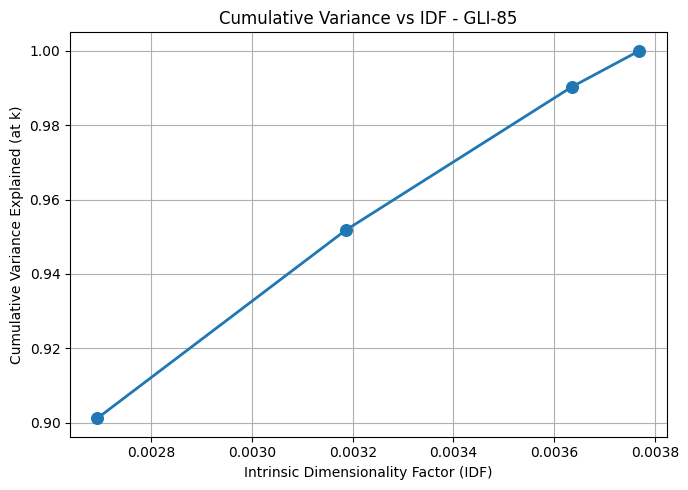


Saved figure paths:
  cumvar_curve: idf_gli85_cumvar_curve.png
  successprob_vs_idf: idf_gli85_successprob_vs_idf.png
  cumvar_vs_idf: idf_gli85_cumvar_vs_idf.png


In [5]:
import pandas as pd
import matplotlib.pyplot as plt

from dynatab.idf_analyzer import TabularIDFAnalyzer, analyze_many

# ------------------------------------------------------------------
# Load datasets
# ------------------------------------------------------------------
datasets = {
    "AI-D":  pd.read_csv("AI-d_case5.csv"),
    "ADNI":  pd.read_csv("ADNI_AD123.csv"),
    "GLI-85": pd.read_csv("GLI-85_encoded.csv"),
}

# If any of these have a label column, you can drop them explicitly, e.g.:
# datasets["AI-D"] = datasets["AI-D"].drop(columns=["label"])
# etc.

# ------------------------------------------------------------------
# Set up analyzer
# ------------------------------------------------------------------
analyzer = TabularIDFAnalyzer(
    variance_thresholds=(0.90, 0.95, 0.99, 0.9975),
    scale="zscore",
    zscore_axis=0,
    impute="mean",
)

# ------------------------------------------------------------------
# Run analysis on all datasets
# ------------------------------------------------------------------
results = analyze_many(datasets, analyzer=analyzer)

# ------------------------------------------------------------------
# Print a compact comparison table first
# ------------------------------------------------------------------
print("=== Dataset-level summary (comparison) ===")
print("Name\t\tMean IDF\tAUC(cumvar vs IDF)\tLoss\t\tComplexity\tFOE")
for name, res in results.items():
    print(
        f"{name:8s}\t"
        f"{res.mean_idf:.6f}\t"
        f"{res.auc_cumvar_vs_idf:.6e}\t"
        f"{res.loss:.6e}\t"
        f"{res.complexity_score:.6e}\t"
        f"{res.foe:.6e}"
    )

# ------------------------------------------------------------------
# Detailed print + plots + saving per dataset
# ------------------------------------------------------------------
for name, res in results.items():
    print("\n" + "=" * 70)
    print(f"=== Detailed IDF / FOE Analysis — {name} ===")
    print("=" * 70)
    print(f"Dataset:              {res.dataset_name}")
    print(f"n_samples x n_features: {res.n_samples} x {res.n_features}")
    print()
    print(f"Mean IDF:             {res.mean_idf:.6f}")
    print(f"AUC (cumvar vs IDF):  {res.auc_cumvar_vs_idf:.6e}")
    print(f"Loss:                 {res.loss:.6e}")
    print(f"Complexity score:     {res.complexity_score:.6e}")
    print(f"FOE:                  {res.foe:.6e}")
    print()

    # Threshold-wise details
    print("Threshold-wise details:")
    print("thr\tk\tIDF\t\tcumvar@k\tP_success")
    for tr in res.threshold_results:
        print(
            f"{tr.variance_threshold:.4f}\t"
            f"{tr.intrinsic_dim:d}\t"
            f"{tr.idf:.6f}\t"
            f"{tr.cumvar_at_k:.6f}\t"
            f"{tr.success_prob:.6f}"
        )

    # --------------------------------------------------------------
    # Display figures for this dataset
    # --------------------------------------------------------------
    # 1) Cumulative explained variance vs components
    fig1, ax1 = plt.subplots(figsize=(8, 5))
    TabularIDFAnalyzer.plot_cumulative_variance_curve(
        result=res,
        ax=ax1,
        title=f"Cumulative Explained Variance - {name}",
    )
    fig1.tight_layout()
    plt.show()

    # 2) Success probability vs IDF
    fig2, ax2 = plt.subplots(figsize=(7, 5))
    TabularIDFAnalyzer.plot_success_prob_vs_idf(
        result=res,
        ax=ax2,
        title=f"Success Probability vs IDF - {name}",
    )
    fig2.tight_layout()
    plt.show()

    # 3) Cumulative variance vs IDF
    fig3, ax3 = plt.subplots(figsize=(7, 5))
    TabularIDFAnalyzer.plot_cumvar_vs_idf(
        result=res,
        ax=ax3,
        title=f"Cumulative Variance vs IDF - {name}",
    )
    fig3.tight_layout()
    plt.show()

    # --------------------------------------------------------------
    # Save plots for this dataset
    # --------------------------------------------------------------
    out_prefix = f"idf_{name.replace(' ', '').replace('-', '').lower()}"
    paths = TabularIDFAnalyzer.save_all_figures(res, out_prefix=out_prefix)
    print("\nSaved figure paths:")
    for k, v in paths.items():
        print(f"  {k}: {v}")

# For multiple datasets but plots on same figure

AI-D: mean_idf=0.220812, auc=0.349842, loss=0.000000, complexity=92.664187
ADNI: mean_idf=0.269886, auc=0.282160, loss=0.000000, complexity=23.359420
GLI-85: mean_idf=0.003321, auc=0.001027, loss=0.000000, complexity=90847.352778


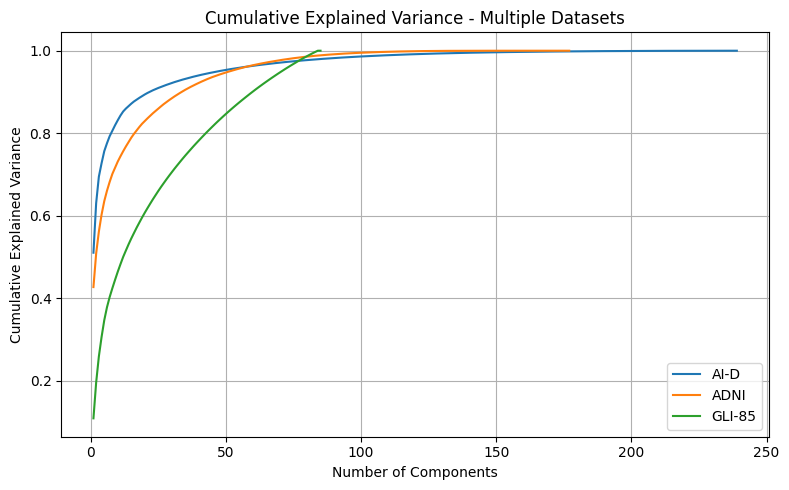

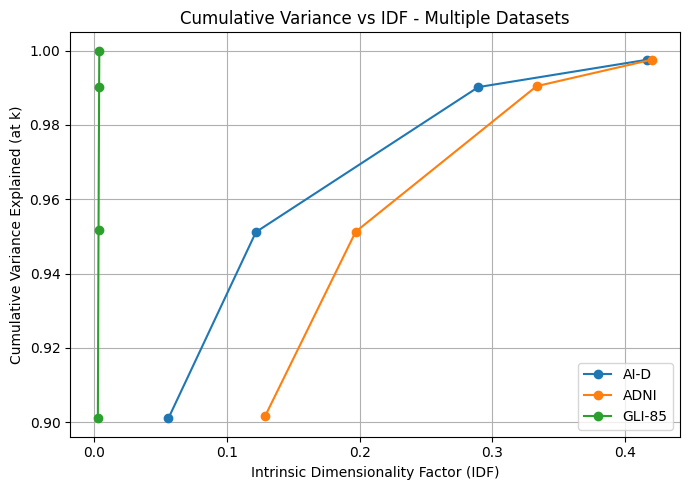

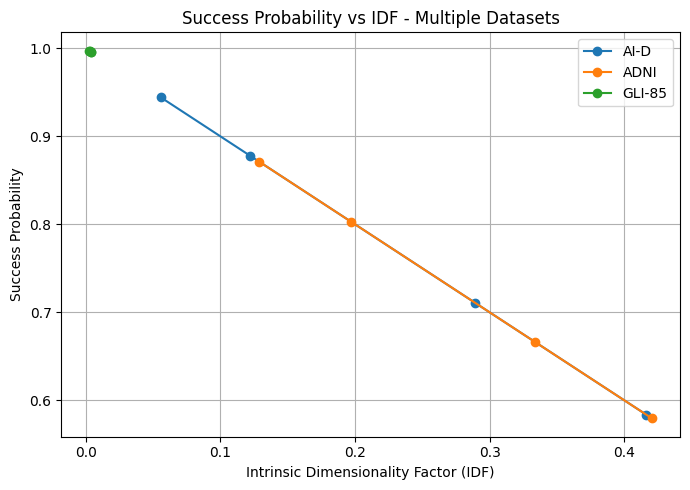

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd  # <- needed
from dynatab.idf_analyzer import IDFAnalysisResult  # optional, just for typing

def plot_cumvar_multi(results_dict, max_components=None, title=None):
    """
    results_dict: {name: IDFAnalysisResult, ...}
    """
    plt.figure(figsize=(8, 5))
    for name, res in results_dict.items():
        cum = np.asarray(res.cumulative_variance, dtype=float)
        if max_components is not None:
            cum = cum[:max_components]
        x = np.arange(1, len(cum) + 1)
        plt.plot(x, cum, label=name)

    plt.xlabel("Number of Components")
    plt.ylabel("Cumulative Explained Variance")
    plt.title(title or "Cumulative Explained Variance - Multiple Datasets")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

def plot_cumvar_vs_idf_multi(results_dict, title=None):
    """
    Plot cumvar@k vs IDF for multiple datasets on the same axes.
    """
    plt.figure(figsize=(7, 5))
    for name, res in results_dict.items():
        x = [tr.idf for tr in res.threshold_results]
        y = [tr.cumvar_at_k for tr in res.threshold_results]

        order = np.argsort(np.asarray(x, dtype=float))
        xs = np.asarray(x, dtype=float)[order]
        ys = np.asarray(y, dtype=float)[order]

        plt.plot(xs, ys, marker="o", label=name)

    plt.xlabel("Intrinsic Dimensionality Factor (IDF)")
    plt.ylabel("Cumulative Variance Explained (at k)")
    plt.title(title or "Cumulative Variance vs IDF - Multiple Datasets")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

def plot_success_prob_vs_idf_multi(results_dict, title=None):
    """
    Plot success probability vs IDF for multiple datasets.
    """
    plt.figure(figsize=(7, 5))
    for name, res in results_dict.items():
        x = [tr.idf for tr in res.threshold_results]
        y = [tr.success_prob for tr in res.threshold_results]

        order = np.argsort(np.asarray(x, dtype=float))
        xs = np.asarray(x, dtype=float)[order]
        ys = np.asarray(y, dtype=float)[order]

        plt.plot(xs, ys, marker="o", label=name)

    plt.xlabel("Intrinsic Dimensionality Factor (IDF)")
    plt.ylabel("Success Probability")
    plt.title(title or "Success Probability vs IDF - Multiple Datasets")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

from dynatab.idf_analyzer import TabularIDFAnalyzer, analyze_many

datasets = {
    "AI-D":   pd.read_csv("AI-d_case5.csv"),
    "ADNI":   pd.read_csv("ADNI_AD123.csv"),
    "GLI-85": pd.read_csv("GLI-85_encoded.csv"),
}

analyzer = TabularIDFAnalyzer(
    variance_thresholds=(0.90, 0.95, 0.99, 0.9975),
    scale="zscore",
    zscore_axis=0,
    impute="mean",
)

results = analyze_many(datasets, analyzer=analyzer)

# ---- PRINT SOME NUMERICAL SUMMARIES ----
for name, res in results.items():
    print(f"{name}: mean_idf={res.mean_idf:.6f}, auc={res.auc_cumvar_vs_idf:.6f}, "
          f"loss={res.loss:.6f}, complexity={res.complexity_score:.6f}")

# ---- DISPLAY COMBINED FIGURES ----
plot_cumvar_multi(results, max_components=None)        # cumvar vs components
plot_cumvar_vs_idf_multi(results)                     # cumvar vs IDF
plot_success_prob_vs_idf_multi(results)               # success prob vs IDF